In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.colors import LinearSegmentedColormap
import os
import networkx as nx
import igraph as ig
import leidenalg as la

ModuleNotFoundError: No module named 'igraph'

In [2]:
# choose basa or GG
database = 'basa' # 'basa' or 'GG'

def get_functional_categories(database):
    if database == 'basa':
        basa_groups = pd.read_csv('../data/basa_groups.csv')
        # make a community_int column with integers from 0 to number of unique communities - 1
        basa_groups['Community_int'] = basa_groups['Community'].astype('category').cat.codes
        basa_partition = basa_groups.set_index('Taxa').to_dict()['Community_int']

        basa_community_index = basa_groups.set_index('Community').to_dict()['Community_int']
        basa_community_index_T = {v: k for k, v in basa_community_index.items()}

        return basa_partition, basa_community_index, basa_community_index_T

if database == 'basa':
    results = 'results_basa'
    data_species = 'GAM_species/species_fit_140_0.01.pkl'
    windows = [(0, 40), (20, 60), (40, 80), (60, 100), (80, 120), (100, 140)]
    windows = [(0, 50), (51, 84), (85, 140)]


species_index = pd.read_pickle(f'{results}/species_index.pkl')
species_index_T = pd.Series(species_index)
species_index_T = pd.Series(species_index_T.index, index = species_index_T.values)
species_index_T = species_index_T.to_dict()

if database == 'basa':
    species_index_non_aq = {k: v for k, v in species_index.items()}
    species_index_T_non_aq = {v: k for k, v in species_index_non_aq.items()}
    non_aq_species = list(species_index_non_aq.keys())

abundances = pd.read_pickle(data_species)
for species in abundances.columns:
    abundances[species]['y'][abundances[species]['y'] < 0] = 0

custom_partition, custom_community_index, custom_community_index_T = get_functional_categories(database)

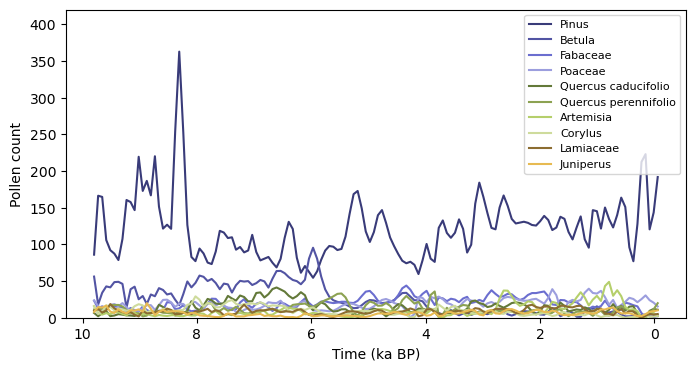

In [3]:
# plot the 10 species (all in the same axes) with highest total abundance over time
abundances_species = pd.DataFrame({k: v['y'] for k, v in abundances.items() if k in species_index_non_aq.keys()})

# sort by total abundance
abundances_species_sum = abundances_species.sum().sort_values(ascending=False)
top_10_species = abundances_species_sum.index[:10]

fig,ax = plt.subplots(figsize=(8, 4))

# get map
colors_sequence = plt.get_cmap('tab20b')(np.linspace(0, .5, len(top_10_species)))

for i,species in enumerate(top_10_species):
    ax.plot(-abundances['Abies']['x']/1000, abundances_species[species], color=colors_sequence[i], alpha=1, label=species)
# invert x axis
ax.invert_xaxis()
ax.set_ylim(0,420)
ax.set_xlabel('Time (ka BP)')
ax.set_ylabel('Pollen count')
ax.legend(loc='upper right', fontsize=8)


In [4]:
# already executed once, no need to do again
def read_bootstrap_GC_networks(causality_name):
    bootstrap_dir = f'{results}/{causality_name}'

    nbootstraps = 1000

    original_table = []
    bootstrapped_p_values = []

    for idx,(start,end) in enumerate(windows):
        try:
            original_table.append(pd.read_pickle(f'{bootstrap_dir}/original_table_{start}-{end}.pkl'))
        except:
            print(f'No original p-values for window {start}-{end}')
            exit(0)

        bootstrapped_p_values.append(np.zeros(original_table[0].shape))

        for b in range(nbootstraps):
            try:
                bootstrap_table = pd.read_pickle(f'{bootstrap_dir}/bootstrap_tables/table_{start}-{end}_bs{b}.pkl')
            except:
                print(f'No bootstrap p-values for window {start}-{end} and bootstrap {b}')
                exit(0)

            bootstrapped_p_values[idx] += (np.abs(bootstrap_table) >= np.abs(original_table[idx])).astype(int)
            
        bootstrapped_p_values[idx] = bootstrapped_p_values[idx] / nbootstraps
        # write the p-values to a file
        pd.to_pickle(bootstrapped_p_values[idx], f'{bootstrap_dir}/bootstrapped_p_values_{start}-{end}.pkl')
    return original_table, bootstrapped_p_values

In [5]:
import networkx as nx

def read_GC_network(causality_name):
    granger_causalities = []
    granger_causalities_p_values = []
    for idx,(start,end) in enumerate(windows):
        granger_causality = pd.read_pickle(f'{results}/{causality_name}/original_table_{start}-{end}.pkl')
        granger_causality[granger_causality > 100] = 0
        granger_causality[granger_causality < -100] = 0
        # granger_causality[np.eye(granger_causality.shape[0], dtype=bool)] = np.nan
        granger_causalities.append(granger_causality)

        granger_causality_p_values = pd.read_pickle(f'{results}/{causality_name}/bootstrapped_p_values_{start}-{end}.pkl')
        granger_causality_p_values[np.eye(granger_causality_p_values.shape[0], dtype=bool)] = np.nan
        granger_causalities_p_values.append(granger_causality_p_values)
    # L = 100
    graphs = []

    for idx,(start,end) in enumerate(windows):
        
        adjacency = granger_causalities_p_values[idx]
        # remove na from the numpy array adjacency
        adjacency = np.nan_to_num(adjacency, nan=1.0)
        # ONLY NON AQUATIC SPECIES
        species_list = list(species_index_T_non_aq.keys())

        cut_value = 0.05

        adjacency_pvalued = (adjacency <= cut_value).astype(int)
        adjacency = granger_causalities[idx] * adjacency_pvalued
        
        graph = nx.from_numpy_array(adjacency, create_using=nx.DiGraph, edge_attr='weight')
        # remove all nodes that are not in the non_aq_species list
        graph.remove_nodes_from([node for node in graph.nodes() if species_index_T[node] not in non_aq_species])
        graphs.append(graph)
        print(cut_value, graph.number_of_edges())
        # currently it's just set to cut a certain value (p=0.05), so it's simple
        
    return granger_causalities, granger_causalities_p_values, graphs

In [6]:
granger_causalities, granger_causalities_p_values, graphs = read_GC_network('bootstrap_conditional_GC/abundances_cond2')

0.05 253
0.05 190
0.05 202


In [7]:
# set functional group as node attribute
for g in graphs:
    for node in g.nodes():
        species = species_index_T_non_aq[node]
        if species in custom_partition:
            g.nodes[node]['functional_group'] = custom_partition[species]
        else:
            g.nodes[node]['functional_group'] = -1 

In [8]:
# group the nodes by functional group and plot the functional groups as nodes, with size proportional to number of species in group and edges' weights proportional to number of links between groups
idx = 1
start, end = windows[idx]

graph = graphs[idx].copy()

# create a new graph with functional groups as nodes
G_fg = nx.MultiDiGraph()
# count number of species in each functional group
fg_counts = {}
for node in graph.nodes():
    fg = graph.nodes[node]['functional_group']
    if fg not in fg_counts:
        fg_counts[fg] = 0
    fg_counts[fg] += 1
for fg, count in fg_counts.items():
    G_fg.add_node(fg, size=count)
# add edges between functional groups
edge_weights = {}
for u, v, data in graph.edges(data=True):
    fg_u = graph.nodes[u]['functional_group']
    fg_v = graph.nodes[v]['functional_group']
    if fg_u != fg_v:
        if (fg_u, fg_v) not in edge_weights:
            edge_weights[(fg_u, fg_v)] = (0, 0)
        if data['weight'] > 0:
            edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0] + 1, edge_weights[(fg_u, fg_v)][1])
        elif data['weight'] < 0:
            edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0], edge_weights[(fg_u, fg_v)][1] + 1)
# add edges to the graph
for (fg_u, fg_v), weight in edge_weights.items():
    G_fg.add_edge(fg_u, fg_v, color = '#0F4C5C', weight=weight[0]*1.5)#
    G_fg.add_edge(fg_u, fg_v, color = '#E36414',  weight=weight[1]*1.5)#


for u, v, key, weight in G_fg.copy().edges(data="weight", keys=True):
    # print(u, v, weight)
    if weight == 0:
        print(f'Edge {u}->{v} has zero weight')
        G_fg.remove_edge(u,v,key)


Edge 7->2 has zero weight
Edge 7->1 has zero weight
Edge 3->7 has zero weight
Edge 6->1 has zero weight
Edge 6->4 has zero weight
Edge 6->7 has zero weight
Edge 6->3 has zero weight
Edge 4->7 has zero weight
Edge 4->3 has zero weight
Edge 0->3 has zero weight
Edge 2->6 has zero weight
Edge 2->7 has zero weight
Edge 5->0 has zero weight


In [1]:

def sequential_custom_generator():
    colors_list = ["#f6ad02","#dbb314","#a1a94a","#88a559","#6ea067","#449d4c","#199a31","#0d841d"] # greens and yellows
    index = 0
    # add randomness to which color we take each time (add a constant seed)
    np.random.seed(42)
    random_indices = np.random.permutation(len(colors_list))
    while True:
        yield mcolors.to_rgb(colors_list[random_indices[index] % len(colors_list)])
        index += 1

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from networkx.drawing.nx_pydot import pydot_layout
import matplotlib.colors as mcolors

from lib.halfarrowpatch import *


def arc3_circle_center(posA, posB, rad):
    A, B = np.array(posA), np.array(posB)
    M = (A + B) / 2
    d = B - A
    L = np.linalg.norm(d)
    n = np.array([-d[1], d[0]]) / L
    h = rad * L / 2
    R = (L**2 / 4 + h**2) / (2 * h)
    C = M + n * (R - L**2 / (8 * h))
    return C, R

def rotate_point(p, center, angle):
    s, c = np.sin(angle), np.cos(angle)
    v = p - center
    return center + np.array([c*v[0] - s*v[1], s*v[0] + c*v[1]])

def add_curved_edge(ax, pos, u, v, color="black", weight=1.5, rad=0.3, angle=0, offset=0.0, node_radius_u=0.05, node_radius_v=0.05, arrowstyle='-|>', zorder=1, **kwargs):

    U = np.array(pos[u])
    V = np.array(pos[v])
    C, R = arc3_circle_center(np.array(pos[u]), np.array(pos[v]), rad)
    
    # Rotate endpoints
    U2 = rotate_point(U, C, np.deg2rad(angle))
    V2 = rotate_point(V, C, np.deg2rad(angle))

    x1, y1 = U2
    x2, y2 = V2

    # Compute direction and perpendicular vectors
    dx, dy = x2 - x1, y2 - y1
    dist = np.sqrt(dx**2 + dy**2)
    dir_vec = np.array([dx, dy]) / dist
    perp = np.array([-dy, dx]) / dist

    # Apply offset (for parallel edges)
    posA = np.array([x1, y1]) + perp * offset + dir_vec * np.sqrt(node_radius_u)
    posB = np.array([x2, y2]) + perp * offset - dir_vec * np.sqrt(node_radius_v)

    arrow = HalfArrowPatch(
        posA=posA,
        posB=posB,
        marker=arrowstyle,
        width=1,
        height=1,
        color=color,
        linewidth=weight,
        curvature=rad,
        zorder=zorder,
        arrow_linewidth=2.5*np.sqrt(weight),
        **kwargs
    )

    ax.add_patch(arrow)

0.019290123456790122
(np.float64(-1.2338101789636955), np.float64(1.1888193701872147)) (np.float64(-1.1829204389945978), np.float64(1.2277581161425997))
0.019290123456790122
(np.float64(-1.2264091846743623), np.float64(1.1545928781616048)) (np.float64(-1.185086829424257), np.float64(1.0415608930992089))
0.019290123456790122
(np.float64(-1.2006833351094364), np.float64(1.2286039683385446)) (np.float64(-1.2864066198865145), np.float64(1.1428806835614664))


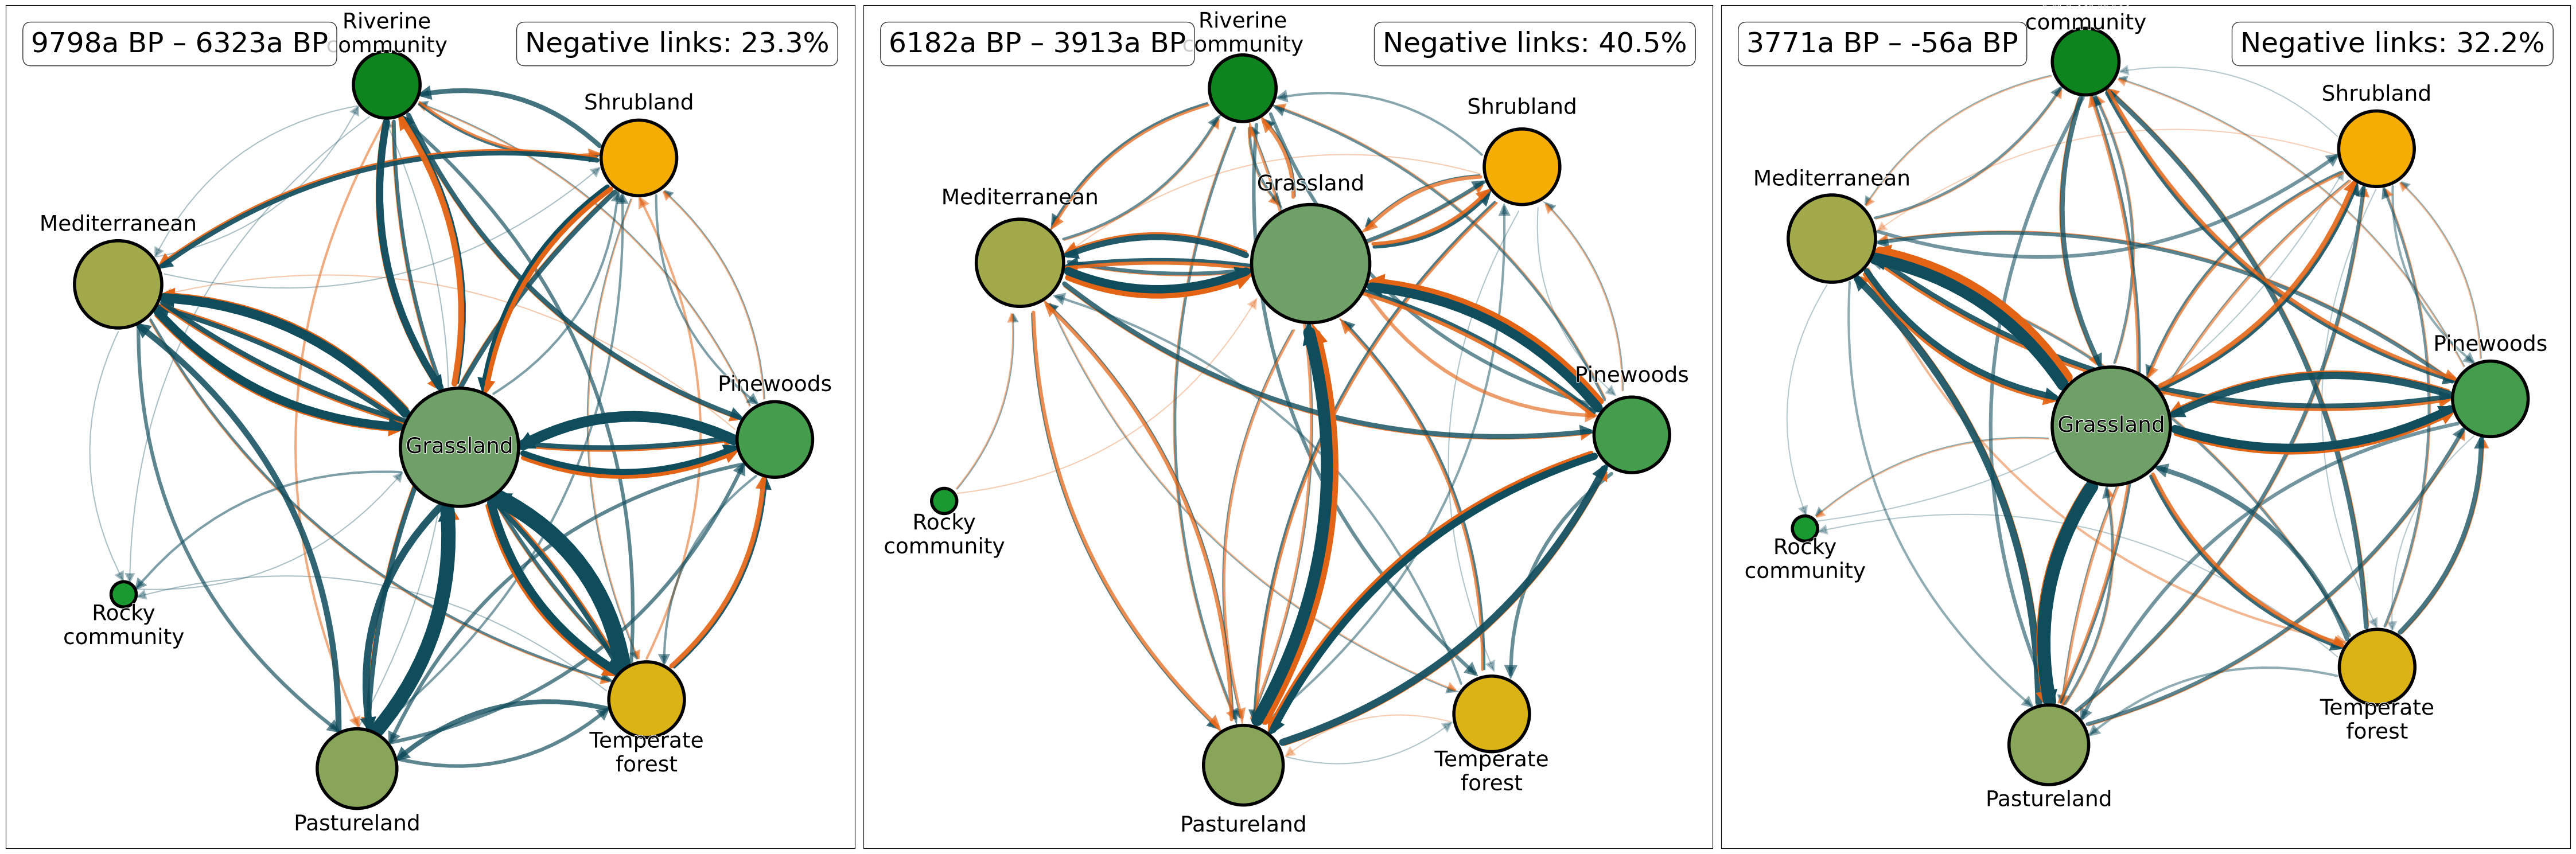

In [11]:
# BASA DE LA MORA
fig, axes = plt.subplots(1,3,figsize=(45, 15))

for idx,(start,end) in enumerate(windows):
# group the nodes by functional group and plot the functional groups as nodes, with size proportional to number of species in group and edges' weights proportional to number of links between groups
    start, end = windows[idx]
    ax = axes[idx]
    graph = graphs[idx].copy()

    # create a new graph with functional groups as nodes
    G_fg = nx.MultiDiGraph()
    # count number of species in each functional group
    fg_counts = {}
    for node in graph.nodes():
        fg = graph.nodes[node]['functional_group']
        if fg not in fg_counts:
            fg_counts[fg] = 0
        fg_counts[fg] += 1
    for fg, count in fg_counts.items():
        G_fg.add_node(fg, size=count)
    # add edges between functional groups
    edge_weights = {}
    for u, v, data in graph.edges(data=True):
        fg_u = graph.nodes[u]['functional_group']
        fg_v = graph.nodes[v]['functional_group']
        if fg_u != fg_v:
            if (fg_u, fg_v) not in edge_weights:
                edge_weights[(fg_u, fg_v)] = (0, 0)
            if data['weight'] > 0:
                edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0] + 1, edge_weights[(fg_u, fg_v)][1])
            elif data['weight'] < 0:
                edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0], edge_weights[(fg_u, fg_v)][1] + 1)
    # add edges to the graph
    for (fg_u, fg_v), weight in edge_weights.items():
        G_fg.add_edge(fg_u, fg_v, color = '#0F4C5C', weight=weight[0]*1.5)#      np.sqrt(weight[0])*2.5)
        G_fg.add_edge(fg_u, fg_v, color = '#E36414',  weight=weight[1]*1.5)#      np.sqrt(weight[1]) *2.5)


    for u, v, key, weight in G_fg.copy().edges(data="weight", keys=True):
        # print(u, v, weight)
        if weight == 0:
            # print(f'Edge {u}->{v} has zero weight')
            G_fg.remove_edge(u,v,key)


    G = G_fg.copy()

    # set initial positions where Grassland (node 0) is at the center, and the others around it in a circle

    labels = {  7: 'Temperate\nforest',
                3: 'Pinewoods',
                6: 'Shrubland',
                4: 'Riverine\ncommunity',
                1: 'Mediterranean',
                2: 'Pastureland',
                0: 'Grassland',
                5: 'Rocky\ncommunity'}
    
    order = {   'Temperate\nforest'    :  1,
                'Pinewoods'  : 2,
                'Shrubland' : 3,
                'Riverine\ncommunity'   : 4,
                'Mediterranean' : 5,
                'Rocky\ncommunity'  : 6,
                'Pastureland' :   7
                 }
    
    N = len(G.nodes())
    initial_pos = {0: np.array([0.0, 0.0])}
    angle_step = 2 * np.pi / (N-1)
    for node, label in labels.items():
        # order nodes in a specific way
        # print(i, labels[node])
        if node != 0:
            angle = angle_step * (order[label]-2)
            initial_pos[node] = np.array([np.cos(angle), np.sin(angle)])

    pos = nx.spring_layout(G, weight = 'weight', seed = 1, pos = initial_pos, iterations=2) # about 2-5 iterations depending on plot
    # pos[5] = np.array([-0.85,-0.5])



    node_sizes = {n:G.nodes[n]['size']*1000 for n in G.nodes()}
    edge_groups = defaultdict(list)
    for u, v, data in G.edges(data=True):
        edge_groups[(u, v)].append(data)

    max_total_weight = max(sum(edge['weight'] for edge in edges) for edges in edge_groups.values())

    renderer = ax.figure.canvas.get_renderer()
    print(renderer.points_to_pixels(1.0)/72)
    community_colors_gen = sequential_custom_generator()
    community_colors = {n: next(community_colors_gen) for n in G.nodes()}

    node_size_scale = 1/700000
    scale = 0.00085  # converts linewidth to offset in data space
    scale = 0.00094  # converts linewidth to offset in data space


    for (u, v), edges in sorted(edge_groups.items(), key=lambda uv_edges: sum(edge['weight'] for edge in uv_edges[1])):
        n = len(edges)
        total_width = sum(edge["weight"] for edge in edges)
        alpha = min(1.1 - np.exp(-4*total_width/max_total_weight), 1)

        if n == 1:
            data = edges[0]
            add_curved_edge(ax, pos, u, v, color=data["color"], weight=data["weight"],
                            rad=0.25, offset=0.0, node_radius_u=node_sizes[u] * node_size_scale,
                            node_radius_v=node_sizes[v]*node_size_scale, zorder=-1,
                            alpha = alpha)
        elif n == 2:
            # Multiple edges draw as touching parallels
            # Compute offsets so they are side-by-side, centered on the main line
            cumulative = 0
            sorted_edges = sorted(edges, key=lambda e: e["weight"])  # sort by width (optional aesthetic)
            w_0 = sorted_edges[0]["weight"]
            w_1 = sorted_edges[1]["weight"]
            offset = (w_0+w_1 / 1.0) * scale

            # set seed
            np.random.seed(0)
            rad = np.random.uniform(0.15,0.25)
            add_curved_edge(ax, pos, u, v, color=sorted_edges[0]["color"], weight=w_0, angle=0,
                            rad=rad, offset=-offset - 0.02, node_radius_u=node_sizes[u]*node_size_scale,
                            node_radius_v=node_sizes[v]*node_size_scale, arrowstyle='|/', zorder = -1,
                            alpha = alpha)
            
            # draw a white node to cover up the tip of the first arrow before drawing the second arrow
            # circle = plt.Circle(pos[u], 1.25*np.sqrt(node_sizes[u]*node_size_scale), color='white', zorder = 0)
            # ax.add_artist(circle)

            add_curved_edge(ax, pos, u, v, color=sorted_edges[1]["color"], weight=w_1,
                            rad=rad, offset=-0.02, node_radius_u=node_sizes[u] * node_size_scale,
                            node_radius_v=node_sizes[v] * node_size_scale, arrowstyle='|\\', zorder=-1,
                            alpha = alpha)

    nx.draw_networkx_nodes(G, pos, node_color=[community_colors[node] for node in G.nodes()], ax=ax, node_size = [node_sizes[n] for n in G.nodes()],
                        edgecolors="black", linewidths=4)
    # custom_community_index_T
    
    # set offset to label positions
    label_pos = {n: pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.001 + 0.06]) if pos[n][1] > 0.1 else
                    pos[n] + np.array([0,-np.sqrt(node_sizes[n])*0.001 - 0.06]) if pos[n][1] < -0.1 else 
                    pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.001 + 0.06]) if pos[n][0] > 0.2 else
                    pos[n] + np.array([0,0.0]) for n in G.nodes()}
    
    texts = nx.draw_networkx_labels(G, pos = label_pos,
                                    ax=ax, labels={n:labels[n] for n in G.nodes()}, font_size = 27, font_color='black')
    for text in texts.values():
            text.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='white'),
                            path_effects.Normal()])
    # set limits to a square
    width = ax.get_xlim()[1] - ax.get_xlim()[0]
    height = ax.get_ylim()[1] - ax.get_ylim()[0]
    if width > height:
        plt.ylim(ax.get_ylim()[0] - (width - height) / 2, ax.get_ylim()[1] + (width - height) / 2)
    else:
        plt.xlim(ax.get_xlim()[0] - (height - width) / 2, ax.get_xlim()[1] + (height - width) / 2)
    # add some margin to the xlim and ylim
    margin = 0.13
    ax.set_ylim(ax.get_ylim()[0] - margin, ax.get_ylim()[1] + margin)
    ax.set_xlim(ax.get_xlim()[0] - margin, ax.get_xlim()[1] + margin)
    print(ax.get_xlim(), ax.get_ylim())
    plt.axis("on")
    plt.tight_layout()
    # set title of the starting and ending years of the time window (set by abundances[species]['x'][start] and abundances[species]['x'][end])
    ax.text(0.03, 0.97, f'{-int(abundances[species_index_T_non_aq[0]]["x"][start])}a BP – {-int(abundances[species_index_T_non_aq[0]]["x"][end-1])}a BP',
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    # now on the top right corner add the percentage of negative links (negative / negative+positive)
    negative_percentage = len([e for e in graph.edges(data=True) if e[2]['weight'] < 0]) / graph.number_of_edges()
    ax.text(0.97, 0.97, f'Negative links: {negative_percentage*100:.1f}%',
            transform=ax.transAxes, fontsize=35,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    # plt.show()
